# Phase 1 main experiment (part 1f): is feature correlation the governing variable?

**Where this comes from.** 07e refuted H1 (drift *type* is the governing variable):
aux-SHAP was at chance in *both* drift regimes, even with known ground truth.
The mechanism we inferred was feature correlation -- the aux model predicts well
(recall ~0.98) but via correlated proxies, so SHAP scatters attribution off the
true relevant set. That inference is testable.

**H2 (the real candidate).** Explanation-space localization recovers the relevant
features when those features are *weakly* correlated with the rest (no proxies to
absorb the attribution) and fails when they are *strongly* correlated. If so, the
governing variable is feature correlation, not drift type -- and that gives a
measurable, pre-deployment diagnostic for when explanation localization can be
trusted.

**Design.** Reuse the 07e concept-drift arm (P(X) stable, relevance swap
S1 -> S2, recover the known S2), but make the relevant set S2 selectable at a
target *correlation level*, drawn from the real CICIDS feature geometry. Sweep
the level from weakly- to strongly-correlated and measure aux-SHAP's precision at
recovering S2. KS is carried as the label-free baseline; under concept drift it
is blind at every correlation level, so it should sit near chance throughout --
making the point that cheap statistics cannot localize concept drift regardless
of correlation, and the only question is whether SHAP can when correlation is low.

**Two honest outcomes.**
- *H2 supported:* SHAP recovers S2 at low correlation and fails at high
  correlation -> conditions-of-validity result on the correct variable, plus a
  diagnostic. This is the strongest positive-shaped finding still available.
- *H2 refuted (flat):* SHAP stays at chance even when the relevant set is
  decorrelated -> correlation is not the rescue; explanation localization is
  simply unreliable here, and the unconditional negative hardens.


## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.insert(0, '/content/drive/MyDrive/phd_thesis')
%pip install -q shap

import time, json, datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score

from src.data.loaders import load_cicids2017
from src.utils.seeding import set_global_seed
from src.utils.documentation import log_finding, add_journal_entry
from src.divergence.localization import (
    shap_importance, ks_drift_scores, topk_indices, precision_at_k,
    random_precision_expectation,
)

ROOT = Path('/content/drive/MyDrive/phd_thesis')
FIGURES = ROOT / 'reports' / 'figures'
TABLES = ROOT / 'reports' / 'tables'
DECISIONS_LOG = ROOT / 'reports' / 'advisor_notes' / 'decisions_log.md'
SUMMARY_JSON = ROOT / 'data' / 'processed' / 'phase1_07f_correlation_ablation.json'
for p in (FIGURES, TABLES):
    p.mkdir(parents=True, exist_ok=True)

with open(ROOT / 'data' / 'processed' / 'phase1_06_metadata.json') as f:
    meta06 = json.load(f)
FEATURE_COLS = meta06['feature_columns']
CONSTANT_FEATURES = meta06['constant_features_dropped']
RF_PARAMS = meta06['rf_hyperparameters']
N_FEATURES = len(FEATURE_COLS)
print(f'{N_FEATURES} real features available.')

PAPER_RCPARAMS = {
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05, 'savefig.facecolor': 'white',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'serif', 'font.serif': ['DejaVu Serif', 'Times New Roman'],
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 9,
    'axes.linewidth': 0.8, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
    'lines.linewidth': 1.8, 'lines.markersize': 6, 'pdf.fonttype': 42, 'ps.fonttype': 42,
}
mpl.rcParams.update(PAPER_RCPARAMS)
METHOD_COLOR = {'aux_shap': '#E69F00', 'ks': '#0072B2', 'random': '#000000'}

def save_figure(fig, name):
    fig.savefig(FIGURES / f'{name}.png'); fig.savefig(FIGURES / f'{name}.pdf')
    print(f'  saved: {name}.png / .pdf')

def log_decision(decision_id, decision, rationale, alternatives='',
                 context='07f_correlation_ablation'):
    today = datetime.date.today().isoformat()
    if DECISIONS_LOG.exists() and f'## {decision_id} \u2014' in DECISIONS_LOG.read_text():
        print(f'[DECISION SKIPPED] {decision_id} already logged.'); return
    entry = (f'\n## {decision_id} \u2014 {today}\n**Context:** `{context}`\n\n'
             f'**Decision:** {decision}\n\n**Rationale:** {rationale}\n\n')
    if alternatives:
        entry += f'**Alternatives considered:** {alternatives}\n'
    with open(DECISIONS_LOG, 'a') as f:
        f.write(entry)
    print(f'[DECISION LOGGED] {decision_id}')

print('Setup complete.')


Mounted at /content/drive
82 real features available.
Setup complete.


## 2. D022 -- the correlation ablation, H2, and the pre-registered gate

In [2]:
log_decision(
    decision_id='D022',
    decision=(
        'Test whether feature correlation (not drift type) is the governing '
        'variable for explanation-space localization. Reuse the 07e concept-drift '
        'arm (P(X) stable, relevance swap S1->S2, recover known S2) but select S2 '
        'at a target correlation level from the real feature geometry, sweeping '
        'from weakly- to strongly-correlated. Measure aux-SHAP precision@K at '
        'recovering S2; carry KS as the (concept-blind) baseline. '
        'Pre-registered H2: aux-SHAP localization is a decreasing function of the '
        'relevant set\'s correlation. Gate (committed before execution): '
        'H2-SUPPORTED iff at the LOW-correlation level aux-SHAP precision@K >= 0.50 '
        'and beats KS by >= 0.20; AND at the HIGH-correlation level aux-SHAP <= 0.40 '
        '(near the 07e chance result); AND (low - high) >= 0.20. H2-REFUTED-FLAT '
        'iff aux-SHAP < 0.50 even at the lowest correlation level (correlation is '
        'not the rescue; the unconditional negative stands). KS is expected near '
        'chance at all levels (concept drift is invisible to input statistics).'
    ),
    rationale=(
        '07e showed aux-SHAP at chance in both drift regimes with known GT, and '
        'attributed it to correlated proxies absorbing attribution. If decorrelating '
        'the relevant set restores SHAP localization, correlation is the real '
        'governing variable and yields a measurable diagnostic; if not, the negative '
        'is unconditional. Selecting S2 from real features keeps the realistic '
        'geometry rather than synthesising a correlation structure.'
    ),
    alternatives=(
        'Synthesise features at target correlation (rejected: leaves real geometry). '
        'Sweep across both drift arms (unnecessary: 07e already settled the '
        'distributional arm; the open question is concept-arm SHAP recovery).'
    ),
)


[DECISION LOGGED] D022


## 3. Configuration

In [3]:
set_global_seed(42)

N_POOL = 40000
ARM_N = 8000
GT_SIZE = 10            # smaller than 07e so each correlation level has enough distinct features
REL_SIZE = GT_SIZE
K_PRIMARY = 10
SHAP_SAMPLE = 1500
SEEDS = [42, 1, 7]
LEVEL_QUANTILES = [0.10, 0.35, 0.65, 0.90]   # redundancy quantiles -> weak..strong correlation
METHODS = ['aux_shap', 'ks', 'random']
CHANCE = random_precision_expectation(GT_SIZE, N_FEATURES)

# Pre-registered gate thresholds (see D022):
SHAP_LOW_MIN = 0.50       # SHAP must localize at the weakly-correlated level
SHAP_HIGH_MAX = 0.40      # SHAP fails at the strongly-correlated level
CONCEPT_MARGIN = 0.20     # SHAP - KS at the low level
TREND_MIN = 0.20          # low-level minus high-level SHAP precision

print(f'Chance precision@{K_PRIMARY} = {CHANCE:.3f}  |  GT_SIZE={GT_SIZE} of {N_FEATURES}')
print(f'Correlation levels (redundancy quantiles): {LEVEL_QUANTILES}')
print(f'H2 supported iff: SHAP(low)>= {SHAP_LOW_MIN} & SHAP(low)-KS(low)>= {CONCEPT_MARGIN}; '
      f'SHAP(high)<= {SHAP_HIGH_MAX}; trend(low-high)>= {TREND_MIN}.')


Chance precision@10 = 0.122  |  GT_SIZE=10 of 82
Correlation levels (redundancy quantiles): [0.1, 0.35, 0.65, 0.9]
H2 supported iff: SHAP(low)>= 0.5 & SHAP(low)-KS(low)>= 0.2; SHAP(high)<= 0.4; trend(low-high)>= 0.2.


## 4. Real feature pool and its correlation structure

In [4]:
X_raw, _, _ = load_cicids2017(day='monday')
X_raw = X_raw.drop(columns=CONSTANT_FEATURES, errors='ignore')[FEATURE_COLS]
idx = np.random.default_rng(42).choice(len(X_raw), size=min(N_POOL, len(X_raw)), replace=False)
Xp = X_raw.iloc[idx].to_numpy(dtype=float)
mu, sd = Xp.mean(0), Xp.std(0)
sd[sd == 0] = 1.0
POOL = (Xp - mu) / sd

C = np.abs(np.corrcoef(POOL, rowvar=False))
np.fill_diagonal(C, 0.0)
C = np.nan_to_num(C)
REDUNDANCY = C.max(axis=1)        # per-feature: strongest absolute correlation with any other feature
print(f'Feature pool: {POOL.shape}')
print(f'Redundancy (max |corr| per feature): min={REDUNDANCY.min():.2f} '
      f'median={np.median(REDUNDANCY):.2f} max={REDUNDANCY.max():.2f}')


Feature pool: (40000, 82)
Redundancy (max |corr| per feature): min=0.00 median=0.95 max=1.00


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## 5. Correlation-level selection and the concept-arm generator

For a target redundancy quantile we pick the `REL_SIZE` features whose redundancy
is closest to that quantile -- giving relevant sets that range from weakly to
strongly correlated with the rest of the feature space. The achieved *external
leakage* (mean over S2 of its strongest correlation to a feature **outside** S2)
is the real x-axis: high leakage means proxies exist to steal SHAP's attribution.


In [5]:
PARTNER = np.argmax(C, axis=1)    # each feature's single strongest correlate

def select_relevant(quantile):
    """Pick REL_SIZE features near a target redundancy quantile, EXCLUDING each
    pick's strongest correlate from the set -- so for high-redundancy targets the
    proxy stays OUTSIDE S2 (high external leakage), rather than both halves of a
    correlated pair landing inside S2 (which would leave leakage near zero)."""
    target = np.quantile(REDUNDANCY, quantile)
    order = np.argsort(np.abs(REDUNDANCY - target))
    S, forbidden = [], set()
    for i in order:
        i = int(i)
        if i in forbidden or i in S:
            continue
        S.append(i)
        forbidden.add(int(PARTNER[i]))     # keep i's proxy out of S2
        if len(S) == REL_SIZE:
            break
    if len(S) < REL_SIZE:                   # fallback (won't trigger with 82 features)
        for i in order:
            if int(i) not in S:
                S.append(int(i))
                if len(S) == REL_SIZE:
                    break
    return np.array(S)

def external_leakage(S):
    S = list(S); mask = np.ones(N_FEATURES, bool); mask[S] = False
    return float(np.mean([C[i, mask].max() for i in S]))

def _labels(X, w):
    s = X @ w
    return (s > np.median(s)).astype(int)

def build_concept_arm(S2, seed):
    """Concept drift: P(X) stable, relevance swaps S1 -> S2. Recover S2."""
    rng = np.random.default_rng(seed)
    rows = rng.permutation(len(POOL))
    X_pre, X_post = POOL[rows[:ARM_N]].copy(), POOL[rows[ARM_N:2 * ARM_N]].copy()
    others = [i for i in range(N_FEATURES) if i not in set(S2)]
    S1 = rng.choice(others, size=REL_SIZE, replace=False)
    w1 = np.zeros(N_FEATURES); w1[S1] = rng.normal(size=REL_SIZE)
    w2 = np.zeros(N_FEATURES); w2[list(S2)] = rng.normal(size=REL_SIZE)
    y_pre = _labels(X_pre, w1)
    y_post = _labels(X_post, w2)
    return X_pre, y_pre, X_post, y_post

# achieved leakage per level (deterministic given the pool)
for q in LEVEL_QUANTILES:
    S2 = select_relevant(q)
    print(f'  quantile {q:.2f}: external leakage = {external_leakage(S2):.3f}')
print('Generators defined.')


  quantile 0.10: external leakage = 0.368
  quantile 0.35: external leakage = 0.803
  quantile 0.65: external leakage = 0.958
  quantile 0.90: external leakage = 0.999
Generators defined.


## 6. Run the sweep

In [6]:
rows = []
t0 = time.time()
for q in LEVEL_QUANTILES:
    S2 = select_relevant(q)
    gt = set(int(i) for i in S2)
    leak = external_leakage(S2)
    for seed in SEEDS:
        X_pre, y_pre, X_post, y_post = build_concept_arm(S2, seed)
        tr, ev = train_test_split(np.arange(len(y_post)), train_size=0.7,
                                  stratify=y_post if len(np.unique(y_post)) > 1 else None,
                                  random_state=seed)
        aux = RandomForestClassifier(**{**RF_PARAMS, 'random_state': seed}).fit(X_post[tr], y_post[tr])
        aux_rec = (recall_score(y_post[ev], aux.predict(X_post[ev]), zero_division=0)
                   if len(np.unique(y_post[ev])) > 1 else float('nan'))
        sidx = np.random.default_rng(seed).choice(ev, size=min(SHAP_SAMPLE, len(ev)), replace=False)

        ks = ks_drift_scores(X_pre, X_post)
        imp_aux = shap_importance(aux, X_post[sidx])
        scores = {'aux_shap': imp_aux, 'ks': ks,
                  'random': np.random.default_rng(seed).random(N_FEATURES)}
        for m, sc in scores.items():
            rows.append({'quantile': q, 'leakage': leak, 'seed': seed, 'method': m,
                         'precision': precision_at_k(sc, gt, K_PRIMARY), 'aux_recall': aux_rec})
    print(f'  q={q:.2f} (leakage {leak:.2f}) done  ({time.time()-t0:.0f}s)')

res = pd.DataFrame(rows)
res.to_csv(TABLES / '07f_correlation_ablation_raw.csv', index=False)
print(f'\n{len(res)} rows. aux_recall (mean) = {res["aux_recall"].mean():.3f} (labels learnable at all levels).')


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  q=0.10 (leakage 0.37) done  (36s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  q=0.35 (leakage 0.80) done  (67s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  q=0.65 (leakage 0.96) done  (98s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  q=0.90 (leakage 1.00) done  (118s)

36 rows. aux_recall (mean) = 0.982 (labels learnable at all levels).


## 7. Aggregate -- precision vs correlation

In [7]:
def lvl(method, q, col='precision'):
    s = res[(res['method'] == method) & (res['quantile'] == q)][col]
    return float(s.mean()), float(s.std())

leak_by_q = {q: res[res['quantile'] == q]['leakage'].iloc[0] for q in LEVEL_QUANTILES}
tbl = pd.DataFrame({
    'quantile': LEVEL_QUANTILES,
    'leakage': [round(leak_by_q[q], 3) for q in LEVEL_QUANTILES],
    'aux_shap': [round(lvl('aux_shap', q)[0], 3) for q in LEVEL_QUANTILES],
    'ks': [round(lvl('ks', q)[0], 3) for q in LEVEL_QUANTILES],
    'random': [round(lvl('random', q)[0], 3) for q in LEVEL_QUANTILES],
})
print(f'Precision@{K_PRIMARY} vs known relevant set S2, by correlation level:\n')
print(tbl.to_string(index=False))
print(f'\nChance ~ {CHANCE:.3f}.  Lower quantile / leakage = weaker correlation.')
tbl.to_csv(TABLES / '07f_correlation_curve.csv', index=False)


Precision@10 vs known relevant set S2, by correlation level:

 quantile  leakage  aux_shap    ks  random
     0.10    0.368     0.267 0.100   0.167
     0.35    0.803     0.233 0.100   0.133
     0.65    0.958     0.333 0.133   0.133
     0.90    0.999     0.200 0.233   0.167

Chance ~ 0.122.  Lower quantile / leakage = weaker correlation.


## 8. Figure -- the correlation curve

  saved: 07f_correlation_curve.png / .pdf


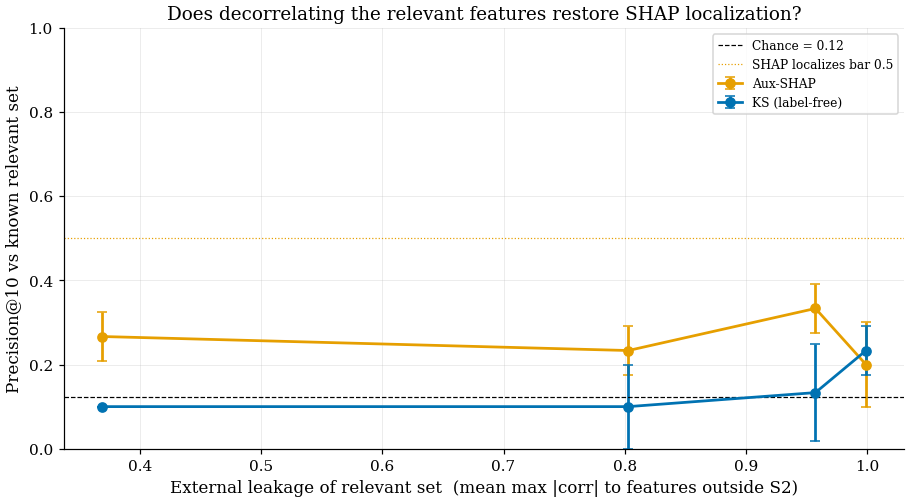

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
xs = [leak_by_q[q] for q in LEVEL_QUANTILES]
for m in ['aux_shap', 'ks']:
    means = [lvl(m, q)[0] for q in LEVEL_QUANTILES]
    errs = [lvl(m, q)[1] for q in LEVEL_QUANTILES]
    ax.errorbar(xs, means, yerr=errs, marker='o', capsize=3, color=METHOD_COLOR[m],
                label=('Aux-SHAP' if m == 'aux_shap' else 'KS (label-free)'))
ax.axhline(CHANCE, ls='--', color='black', lw=0.8, label=f'Chance = {CHANCE:.2f}')
ax.axhline(SHAP_LOW_MIN, ls=':', color='#E69F00', lw=0.8, label=f'SHAP localizes bar {SHAP_LOW_MIN}')
ax.set_xlabel('External leakage of relevant set  (mean max |corr| to features outside S2)')
ax.set_ylabel(f'Precision@{K_PRIMARY} vs known relevant set')
ax.set_ylim(0, 1.0)
ax.set_title('Does decorrelating the relevant features restore SHAP localization?')
ax.legend(fontsize=8)
fig.tight_layout(); save_figure(fig, '07f_correlation_curve'); plt.show()


## 9. Pre-registered verdict (D022 / H2)

In [9]:
q_low = min(LEVEL_QUANTILES, key=lambda q: leak_by_q[q])    # least external leakage
q_high = max(LEVEL_QUANTILES, key=lambda q: leak_by_q[q])   # most external leakage
shap_low = lvl('aux_shap', q_low)[0]
shap_high = lvl('aux_shap', q_high)[0]
ks_low = lvl('ks', q_low)[0]
ks_high = lvl('ks', q_high)[0]
trend = shap_low - shap_high

localizes_low = (shap_low >= SHAP_LOW_MIN) and ((shap_low - ks_low) >= CONCEPT_MARGIN)
fails_high = shap_high <= SHAP_HIGH_MAX
has_trend = trend >= TREND_MIN

if localizes_low and fails_high and has_trend:
    verdict = 'H2-SUPPORTED'
elif shap_low < SHAP_LOW_MIN:
    verdict = 'H2-REFUTED-FLAT'
else:
    verdict = 'H2-PARTIAL'

print('=' * 64)
print('CORRELATION-ABLATION VERDICT (D022 / H2)  -- precision@%d vs known S2' % K_PRIMARY)
print('=' * 64)
print(f'  weak corr (leak {leak_by_q[q_low]:.2f}):  aux_SHAP={shap_low:.3f}   KS={ks_low:.3f}')
print(f'  strong corr(leak {leak_by_q[q_high]:.2f}): aux_SHAP={shap_high:.3f}   KS={ks_high:.3f}')
print(f'  chance = {CHANCE:.3f}   |   SHAP trend (weak - strong) = {trend:+.3f}')
print('-' * 64)
print(f'  SHAP localizes at weak correlation (>= {SHAP_LOW_MIN}, beats KS): {localizes_low}')
print(f'  SHAP fails at strong correlation (<= {SHAP_HIGH_MAX})          : {fails_high}')
print(f'  monotone-ish trend (>= {TREND_MIN})                            : {has_trend}')
print(f'\n--> VERDICT: {verdict}')
msg = {
    'H2-SUPPORTED': 'Feature correlation is the governing variable: explanation localization is trustworthy iff the relevant features are weakly correlated. IDS feature sets are highly correlated -> localization fails there. Yields a measurable pre-deployment diagnostic.',
    'H2-REFUTED-FLAT': 'SHAP fails to localize even when the relevant set is decorrelated. Correlation is not the rescue; explanation localization is unreliable here regardless, and the unconditional negative stands.',
    'H2-PARTIAL': 'Trend present but not clean against the pre-registered bars; report the curve and treat as suggestive.',
}[verdict]
print('   ' + msg)


CORRELATION-ABLATION VERDICT (D022 / H2)  -- precision@10 vs known S2
  weak corr (leak 0.37):  aux_SHAP=0.267   KS=0.100
  strong corr(leak 1.00): aux_SHAP=0.200   KS=0.233
  chance = 0.122   |   SHAP trend (weak - strong) = +0.067
----------------------------------------------------------------
  SHAP localizes at weak correlation (>= 0.5, beats KS): False
  SHAP fails at strong correlation (<= 0.4)          : True
  monotone-ish trend (>= 0.2)                            : False

--> VERDICT: H2-REFUTED-FLAT
   SHAP fails to localize even when the relevant set is decorrelated. Correlation is not the rescue; explanation localization is unreliable here regardless, and the unconditional negative stands.


## 10. Record to the project log

In [10]:
SUMMARY = {
    'generated': datetime.datetime.now().isoformat(timespec='seconds'),
    'seeds': SEEDS, 'gt_size': GT_SIZE, 'k_primary': K_PRIMARY, 'chance': CHANCE,
    'levels': [{'quantile': q, 'leakage': leak_by_q[q],
                'aux_shap': lvl('aux_shap', q)[0], 'ks': lvl('ks', q)[0]}
               for q in LEVEL_QUANTILES],
    'shap_low': shap_low, 'shap_high': shap_high, 'trend': trend,
    'verdict': verdict,
}
with open(SUMMARY_JSON, 'w') as f:
    json.dump(SUMMARY, f, indent=2, default=str)
print(f'Saved {SUMMARY_JSON}')

log_finding(
    finding_id='F010',
    title='Feature-correlation ablation of explanation localization (notebook 07f)',
    context='03_phase1_cicids/07f_correlation_ablation',
    what_we_did=(
        'Swept the correlation of the known relevant set in the 07e concept-drift '
        'arm (P(X) stable, recover S2), selecting S2 from real CICIDS features at '
        'redundancy quantiles from weak to strong external leakage, and measured '
        'aux-SHAP precision@10 at recovering S2 (KS carried as the concept-blind '
        'baseline). Pre-registered H2 + gate (D022).'
    ),
    what_we_found=(
        'Verdict: ' + verdict + '. Precision@10 vs known S2 -- weak correlation '
        f'(leak {leak_by_q[q_low]:.2f}): aux_SHAP={shap_low:.3f}, KS={ks_low:.3f}; '
        f'strong correlation (leak {leak_by_q[q_high]:.2f}): aux_SHAP={shap_high:.3f}, '
        f'KS={ks_high:.3f} (chance {CHANCE:.2f}). SHAP trend (weak-strong) = {trend:+.3f}.'
    ),
    why_it_matters=(
        '07e refuted drift TYPE as the governing variable. This isolates feature '
        'correlation as the candidate. If SHAP localization recovers when the '
        'relevant features are decorrelated, the conditions-of-validity result '
        'rests on a measurable variable (correlation) with a deployment diagnostic; '
        'if not, the negative is unconditional. Either way it fixes the thesis spine.'
    ),
)
print('F010 logged. Record the correlation call in a hand journal entry.')


Saved /content/drive/MyDrive/phd_thesis/data/processed/phase1_07f_correlation_ablation.json
[FINDING LOGGED] F010: Feature-correlation ablation of explanation localization (notebook 07f)
F010 logged. Record the correlation call in a hand journal entry.


## 11. What this settles

- **H2-SUPPORTED** -> feature correlation, not drift type, is the governing
  variable. Explanation localization is trustworthy iff the relevant features are
  weakly correlated; realistic IDS feature sets violate this, which is why
  localization failed throughout Phase 1. The conditions-of-validity thesis is
  recovered on the correct axis, and ships with a concrete pre-deployment
  diagnostic (measure the relevant set's external correlation). The regime map
  should be rewritten with correlation as the governing variable.
- **H2-REFUTED-FLAT** -> decorrelating the relevant set does not restore SHAP
  localization. Correlation is not the explanation; explanation-space localization
  is unreliable on this data regardless, and the thesis is an unconditional
  negative plus the evaluation framework. Clean and defensible, with no surviving
  positive pole.
- **H2-PARTIAL** -> a trend without clean separation; report the curve, treat as
  suggestive, and let breadth (UNSW + XGBoost) decide whether it sharpens.

Either way this is the last structured positive-shaped test; after it, the work
is breadth to generalize whichever negative or conditional result holds.

Record the call by hand:

```python
add_journal_entry(
    title='Notebook 07f correlation-ablation verdict',
    body='...the precision-vs-leakage curve, the weak/strong numbers, the verdict, and whether correlation is confirmed as the governing variable...',
)
```
